In [1]:
from utils_00 import *
# exec(open('c00_utils.py').read())

pn.extension()  # 启用 Jupyter 支持
pd.set_option('expand_frame_repr', False)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', 100)

In [2]:
native_exchange_data_dir = os.path.join(base_dir, "Native_Exchange_Data")
temporary_experimental_data_dir = os.path.join(base_dir, "Temporary_Experimental_Data")
pro = ts.pro_api(secret_dict['tushare']['api_key'])

def get_exchange_variety_map():
    # 交易所日历路径 NED_dimension_exchange_calendar_path
    NED_dimension_exchange_calendar_path = os.path.join(native_exchange_data_dir, 'dimension_exchange_calendar.csv')
    dimension_exchange_calendar = pd.read_csv(NED_dimension_exchange_calendar_path, dtype = {'date': str})

    # 获取 交易所-品种 表单
    exchange_list = [col for col in dimension_exchange_calendar.columns if col != 'date'] # 交易所列表
    map_list = []
    for exchange in exchange_list:

        exchange_variety_map = pd.DataFrame()
        for attempt in range(3):
            try:
                exchange_variety_map = pro.fut_basic(exchange = exchange, fut_type = "1", fields = ["fut_code"])
                break
            except Exception as e:
                print(f"第 {attempt + 1} 次获取 {exchange} 品种信息失败: {e}")

        exchange_variety_map = exchange_variety_map.drop_duplicates()
        exchange_variety_map["exchange"] = exchange
        map_list.append(exchange_variety_map)

    exchange_variety_map = pd.concat(map_list, ignore_index = True)
    exchange_variety_map = exchange_variety_map.groupby('exchange')['fut_code'].apply(list)
    exchange_variety_map = exchange_variety_map.to_dict()
    return exchange_variety_map

if __name__ == '__main__':
    exchange_variety_map = get_exchange_variety_map()
    exchange_variety_map.pop("CZCE")
    exchange_variety_map.pop("DCE")
    print(exchange_variety_map)

{'CFFEX': ['T', 'TF', 'IF', 'IM', 'IC', 'IH', 'TS', 'TL'], 'GFEX': ['LC', 'SI', 'PS', 'PD', 'PT'], 'INE': ['NR', 'SC', 'LU', 'BC', 'SCTAS', 'EC'], 'SHFE': ['AO', 'NI', 'AL', 'HC', 'BU', 'RU', 'FU', 'CU', 'AG', 'ZN', 'AU', 'PB', 'SS', 'RB', 'SN', 'WR', 'SP', 'BR', 'AD', 'OP']}


In [3]:
exchange = None
variety = None

if __name__ == '__main__':
    # 交易所选择组件
    exchange_radio = widgets.RadioButtons(
        options = list(exchange_variety_map.keys()),
        description = '交易所选择 exchange:',
        layout = {'width': '400px'}
    )

    # 品种选择组件（初始禁用）
    species_toggle = widgets.ToggleButtons(
        options = [],
        description = '品种选择 variety:',
        disabled = True,
        button_style = '',
        style = {'button_width': 'auto'},
        layout = widgets.Layout(width = '600px'),
    )

    # 输出提示区域
    out = widgets.Textarea(
        value = '请先选择交易所，然后选择品种',
        layout = {'width': '400px', 'height': '50px'},
        disabled = True
    )

    display(widgets.VBox([exchange_radio, species_toggle, out]))

    def on_exchange_change(change):
        """当交易所改变时，更新可选品种"""
        global exchange
        if change['name'] == 'value':
            exchange = change['new']
            varieties = exchange_variety_map.get(exchange, [])
            species_toggle.options = sorted(varieties)
            species_toggle.disabled = len(varieties) == 0
            if varieties:
                species_toggle.value = varieties[0]  # 默认选第一个
                out.value = f'已选择交易所：{exchange}，请选择品种'
            else:
                out.value = f'交易所 {exchange} 无可用品种'

    def on_species_change(change):
        """当品种改变时，记录到全局变量"""
        global variety
        if change['name'] == 'value' and species_toggle.options:
            variety = change['new']
            out.value = f'已选择交易所 exchange: {exchange}\n已选择品种 variety: {variety}'

    # 绑定事件 ["SCTAS", "SI", "FU", "AU", "SS", "WR"]
    exchange_radio.observe(on_exchange_change, names = 'value')
    species_toggle.observe(on_species_change, names = 'value')

In [4]:
dataset_range_boundary = ""  # 选择的时间范围边界字符串

if __name__ == '__main__':

    # 临时实验数据品种文件夹路径 TED_variety_path
    TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))
    dataset_range = os.listdir(TED_variety_path)
    dataset_range = sorted(dataset_range)

    dataset_range_buttons = []  # 创建数据集范围边界按钮容器
    for range_file in dataset_range:  # 为每个范围文件创建按钮
        btn = widgets.Button(
            description = range_file,
            layout = {'width': '530px', 'height': '25px'},  # 宽度较大以显示完整文件名
            button_style = ''
        )
        dataset_range_buttons.append(btn)

    dataset_range_button_column = widgets.VBox(dataset_range_buttons) # Horizontal Box & Vertical Box

    # 输出显示区域
    range_display_output = widgets.Textarea(
        value = 'dataset_range_boundary: 未选择',
        layout = {'width': '530px', 'height': '30px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([
        widgets.Label('数据集范围边界 dataset_range_boundary:'),
        dataset_range_button_column,
        range_display_output
    ]))

    def update_range_display():
        """更新显示区域"""
        global dataset_range_boundary
        range_display_output.value = f'dataset_range_boundary: {dataset_range_boundary}'

    def set_dataset_range_boundary(range_file):
        """设置数据集范围边界"""
        global dataset_range_boundary
        dataset_range_boundary = range_file
        update_range_display()

    # 事件处理函数
    def on_dataset_range_button_click(btn):
        """数据集范围按钮 点击事件"""
        set_dataset_range_boundary(btn.description)

    # 绑定事件
    for btn in dataset_range_buttons:
        btn.on_click(on_dataset_range_button_click)

    # 初始化
    update_range_display()

In [5]:
tick_granularity = 0  # 采样颗粒度 全局变量
resample_axis = None  # 采样轴 全局变量

if __name__ == '__main__':

    # 创建 tick_granularity 输入框组件
    tick_granularity_input = widgets.IntText(
        value = 0,
        description = 'tick_granularity:',
        layout = {'width': '250px', 'height': '25px'},
        style = {'description_width': '90px'},
        continuous_update = False
    )

    # 创建 tick_granularity 按钮容器
    granularity_buttons = []
    for i in [i for i in range(0, 181, 15)]:
        btn = widgets.Button(
            description = str(i),
            layout = {'width': '45px', 'height': '25px'}
        )
        btn.value = i
        granularity_buttons.append(btn)
    granularity_button_row = widgets.HBox(granularity_buttons)

    # tick_granularity 输出显示区域
    granularity_out = widgets.Textarea(
        value = '当前 tick_granularity: 0',
        layout = {'width': '400px', 'height': '30px'},
        disabled = True
    )

    # 创建 resample_axis 按钮
    axis_buttons = []
    axis_options = ['time_axis_data', 'volume_axis_data', 'money_axis_data']  # 重采样刻度选项
    for option in axis_options:
        btn = widgets.Button(
            description = option,
            layout = {'width': '135px', 'height': '25px'}
        )
        btn.value = option
        axis_buttons.append(btn)
    axis_button_row = widgets.HBox(axis_buttons)

    # resample_axis 显示区域
    axis_out = widgets.Textarea(
        value = '当前 resample_axis: None',
        layout = {'width': '400px', 'height': '30px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([tick_granularity_input, granularity_button_row, granularity_out, axis_button_row, axis_out]))

    def update_display(value):
        """更新显示"""
        global tick_granularity
        tick_granularity = value
        granularity_out.value = f'当前 tick_granularity: {tick_granularity}'
        tick_granularity_input.value = value

    def update_axis_display(value):
        """更新 resample_axis 显示"""
        global resample_axis
        resample_axis = value
        axis_out.value = f'当前 resample_axis: {resample_axis}'

    def on_input_change(change):
        """当输入框值改变时"""
        if change['name'] == 'value':
            new_value = change['new']
            if 0 <= new_value <= 600:
                update_display(new_value)
            else:
                tick_granularity_input.value = tick_granularity  # 恢复原值

    def on_button_click(btn):
        """当按钮点击时"""
        new_value = btn.value
        update_display(new_value)

    def on_axis_button_click(btn):
        """当 resample_axis 按钮点击时"""
        new_value = btn.value
        update_axis_display(new_value)

    # 绑定输入框事件
    tick_granularity_input.observe(on_input_change, names ='value')

    # 绑定所有按钮事件
    for btn in granularity_buttons:
        btn.on_click(on_button_click)

    # 绑定 resample_axis 按钮事件
    for btn in axis_buttons:
        btn.on_click(on_axis_button_click)

In [6]:
lookback_months = 0  # 回溯月份数 全局变量
split_index = None  # 切割点 index 全局变量
split_time_str = None  # 切割时间字符串 全局变量

if __name__ == '__main__':

    TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))  # 临时实验数据品种文件夹路径 TED_variety_path
    dataset_range_boundary_path = os.path.join(TED_variety_path, dataset_range_boundary)  # 时间范围文件夹路径 dataset_range_boundary_path
    tick_granularity_resample_path = os.path.join(dataset_range_boundary_path, f'tick_granularity_{tick_granularity}')  # 采样刻度文件路径 tick_granularity_resample_path
    resample_axis_data_path = os.path.join(tick_granularity_resample_path, resample_axis)  # 驱动轴数据文件路径 resample_axis_data_path

    tick_type_dict = {
        'time_axis_data': 'Nrow',
        'volume_axis_data': 'volume',
        'money_axis_data': 'money'
    }
    if resample_axis in tick_type_dict.keys():
        tick_type = tick_type_dict[resample_axis]
    else: raise ValueError

    # 主力片段拼接重采样时间索引路径 main_continuous_resampled_date_index_path
    main_continuous_resampled_date_index_path = os.path.join(resample_axis_data_path, rf"main_continuous_{tick_type}_date_index.csv")
    main_continuous_resampled_date_index = pd.read_csv(main_continuous_resampled_date_index_path, dtype = {'date': str})

    # 创建 lookback_months 输入框组件
    lookback_months_input = widgets.IntText(
        value = 0,
        description = 'lookback_months:',
        layout = {'width': '250px', 'height': '25px'},
        style = {'description_width': '100px'},
        continuous_update = False
    )

    # 创建 lookback_months 按钮容器（1~24）
    months_buttons = []
    for i in range(1, 25):
        btn = widgets.Button(
            description = str(i),
            layout = {'width': '45px', 'height': '25px'}
        )
        btn.value = i
        months_buttons.append(btn)
    first_row = widgets.HBox(months_buttons[:12])   # 前12个按钮
    second_row = widgets.HBox(months_buttons[12:])  # 后12个按钮
    months_button_row = widgets.VBox([first_row, second_row])

    # 输出显示区域：包含回溯月份、切割index、切割时间
    split_info_out = widgets.Textarea(
        value = '当前 lookback_months: \nsplit_index: None \nsplit_time_str: None',
        layout = {'width': '600px', 'height': '60px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([lookback_months_input, months_button_row, split_info_out]))

    def update_split_info():
        """根据 lookback_months 和 main_continuous_resampled_date_index 计算并更新 split_index 与 split_time_str"""
        global lookback_months, split_index, split_time_str

        if lookback_months <= 0 or main_continuous_resampled_date_index.empty:
            split_index = None
            split_time_str = None
        else:
            # 获取最后一行的时间字符串并转换为 datetime
            last_time_str = main_continuous_resampled_date_index['date'].iloc[-1]
            last_dt = pd.to_datetime(last_time_str)

            # 回溯指定月份数（注意：pandas 的 DateOffset 支持月份偏移）
            target_dt = last_dt - pd.DateOffset(months=lookback_months)

            # 找到最接近但不大于 target_dt 的行的 index
            date_series = pd.to_datetime(main_continuous_resampled_date_index['date'])
            valid_mask = date_series <= target_dt
            if valid_mask.any():
                split_index = valid_mask[::-1].idxmax()  # 最后一个满足条件的 index
                split_time_str = main_continuous_resampled_date_index['date'].iloc[split_index]
            else:
                split_index = 0
                split_time_str = main_continuous_resampled_date_index['date'].iloc[0]

        # 更新显示
        split_info_out.value = f'当前 lookback_months: {lookback_months} \nsplit_index: {split_index} \nsplit_time_str: {split_time_str}'

    def on_months_input_change(change):
        """当输入框值改变时"""
        if change['name'] == 'value':
            new_value = change['new']
            if 0 <= new_value <= 24:
                global lookback_months
                lookback_months = new_value
                lookback_months_input.value = new_value
                update_split_info()
            else:
                lookback_months_input.value = lookback_months  # 恢复原值

    def on_months_button_click(btn):
        """当按钮点击时"""
        global lookback_months
        lookback_months = btn.value
        lookback_months_input.value = lookback_months
        update_split_info()

    # 绑定输入框事件
    lookback_months_input.observe(on_months_input_change, names='value')

    # 绑定所有按钮事件
    for btn in months_buttons:
        btn.on_click(on_months_button_click)

    # 初始化显示
    update_split_info()

In [7]:
# 临时实验数据品种文件夹路径 TED_variety_path
TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))

# 时间范围文件夹路径 dataset_range_boundary_path
dataset_range_boundary_path = os.path.join(TED_variety_path, dataset_range_boundary)

# 采样刻度文件路径 tick_granularity_resample_path
tick_granularity_resample_path = os.path.join(dataset_range_boundary_path, f'tick_granularity_{tick_granularity}')

# 驱动轴数据文件路径 resample_axis_data_path
resample_axis_data_path = os.path.join(tick_granularity_resample_path, resample_axis)



tick_type_dict = {
    'time_axis_data': 'Nrow',
    'volume_axis_data': 'volume',
    'money_axis_data': 'money'
}
if resample_axis in tick_type_dict.keys():
    tick_type = tick_type_dict[resample_axis]
else: raise ValueError

# 主力片段拼接重采样序列文件路径 main_continuous_resampled_timeseries_path
main_continuous_resampled_timeseries_path = os.path.join(resample_axis_data_path, f'main_continuous_{tick_type}_timeseries.csv')
main_continuous_resampled_timeseries = pd.read_csv(main_continuous_resampled_timeseries_path, dtype = {'date': str})

# 主力片段拼接重采样时间索引路径 main_continuous_resampled_date_index_path
main_continuous_resampled_date_index_path = os.path.join(resample_axis_data_path, f'main_continuous_{tick_type}_timeseries.csv')
main_continuous_resampled_date_index = pd.read_csv(main_continuous_resampled_date_index_path, dtype = {'date': str})

# 同步压缩变换 SWT 数据路径 CWT_SWT_path
CWT_SWT_path = os.path.join(resample_axis_data_path, f'CWT_SWT')
os.makedirs(CWT_SWT_path, exist_ok = True)

# SWT 实部数据路径 SWT_real_path
SWT_real_path = os.path.join(CWT_SWT_path, f'SWT_real.csv')

# SWT 虚部数据路径 SWT_imag_path
SWT_imag_path = os.path.join(CWT_SWT_path, f'SWT_imag.csv')

# SWT 幅值数据路径 SWT_magnitude_path
SWT_magnitude_path = os.path.join(CWT_SWT_path, f'SWT_magnitude.csv')

# SWT 相位数据路径 SWT_phase_path
SWT_phase_path = os.path.join(CWT_SWT_path, f'SWT_phase.csv')

# SWT 频率映射表路径 frequencies_map_path
frequencies_map_path = os.path.join(CWT_SWT_path, f'frequencies_map.csv')

### 1.1 复 Morlet 小波 Complex Morlet Wavelet

 > ##### 母小波公式 (Mother Wavelet):
$\psi(t) = (\pi f_b)^{-0.5} \cdot e^{i 2\pi f_c t} \cdot e^{-t^2 / f_b}$

 > ##### 尺度化小波函数 (Scaled Wavelet):
$\psi_{\text{scale}}(t) = \frac{1}{\sqrt{\text{scale}}} \cdot (\pi f_b)^{-0.5} \cdot e^{i 2\pi f_c \cdot (t/\text{scale})} \cdot e^{-(t/\text{scale})^2 / f_b}$

 > ##### 尺度-频率转换 (Scale-Frequency Conversion):
$f = \frac{f_c}{\text{scale} \cdot \Delta}$

In [8]:
class ComplexMorletWavelet:
    """ 复 Morlet 小波 (cmor1.5-1.0)
    fc : float 中心频率 (默认1.5 Hz)
    fb : float 带宽参数 (默认1.0)
    小波公式: psi(t) = (pi*fb)^(-0.5) * exp(i*2*pi*fc*t) * exp(-t^2/fb) """

    def __init__(self, fc = 1.5, fb = 1.0):
        self.fc = fc  # 中心频率
        self.fb = fb  # 带宽参数

    def __call__(self, t, scale = 1.0):
        """ 计算复 Morlet 小波值
        Parameters:
        t : array_like 时间/交易量轴采样点
        scale : float 尺度参数

        Returns:
        psi : complex array 复 Morlet 小波值 (实部 + i*虚部) """

        t_scaled = t / scale  # 归一化时间

        norm = (np.pi * self.fb) ** (-0.5)
        gaussian_envelope = np.exp(-t_scaled**2 / self.fb)
        complex_exponential = np.exp(1j * 2 * np.pi * self.fc * t_scaled)  # 复 Morlet 小波公式
        # 小波基函数是连续函数 psi(t)
        # psi_{a,b}(t) = (1/sqrt(a)) * psi((t-b)/a)
        # a = scale（尺度）
        # b = 平移参数（在 ssqueezepy 内部通过卷积/FFT 隐式处理）
        # t = 连续时间变量

        psi = norm * complex_exponential * gaussian_envelope / np.sqrt(scale)
        # 复 Morlet 小波在特定尺度 scale 和时间点 t 处的复数值（实部 + i*虚部）
        return psi  # Ψ（psi）

    def get_center_frequency(self, scale, delta = 1.0):
        """ 获取给定尺度对应的中心频率
        Parameters:
        scale : float 尺度参数
        delta : float 采样间隔（在交易量域中为1，因为是等距采样）

        Returns:
        f : float 中心频率 (cycles per sample) """

        # 中心频率 = fc / (scale * delta)
        return self.fc / (scale * delta)

### 1.2 连续小波变换 WaveletCWT

 > ##### CWT卷积公式 (CWT Convolution):
$W_x(\text{scale}, n) = x_{\text{extended}}(n) * \psi_{\text{scale}}(n) = \sum_{m} x_{\text{extended}}(m) \cdot \psi_{\text{scale}}^*(n-m)$

 > ##### 窗口末端索引 (Endpoint Index):
$\text{idx}_{\text{endpoint}} = L + N - 1$

In [9]:
class WaveletCWT:

    def __init__(self, wavelet = None, scales = None, sampling_interval = 1.0):
        """ Parameters:
        wavelet : Complex Morlet Wavelet 小波函数，默认使用 cmor1.5-1.0
        scales : array_like 尺度数组，如果为 None 则自动生成对数尺度
        sampling_interval : float 采样间隔 """

        self.wavelet = wavelet if wavelet is not None else ComplexMorletWavelet(fc = 1.5, fb = 1.0)

        self.sampling_interval = sampling_interval
        # sampling_interval: 采样间隔 Δ 是序列中相邻两点之间的物理距离。对于时间序列，单位通常是秒、分钟等；对于交易量轴数据，单位可以是吨、手等交易量单位。也可以用样本数作为周期单位，即数字频率，此时设置 dt = 1 即可。
        # 通过 Δ 可计算采样频率 f_s = 1/Δ，进而确定奈奎斯特频率 f_N = f_s/2（离散信号能正确表示的最高频率）。
        # 同时 Δ 可将小波尺度 s 转换为实际频率 f = f_c⋅f_s/s，其中 f_c 是小波中心频率。这个频率值可用于与外部时间/交易量单位对齐。

        # 数字频率（Digital Frequency）是离散信号处理中用来描述信号频率的一种归一化表示方式。它将频率与采样过程联系起来，使得频率值仅取决于样本索引，而与采样间隔的具体物理单位无关。
        # 对于一个等间隔采样的离散序列，采样间隔为 Δ（单位可以是秒、分钟、交易量单位等），采样频率为 f_s=1/Δ。设信号的物理频率为 f（单位与 Δ 的倒数一致，如 Hz 或 “周期/交易量单位”），则归一化数字频率 f_d 定义为：f_d = f/f_s

        self.scales = np.array(scales)
        # 处理金融时间序列这类非平稳、非周期信号时，我们无法像处理语音或地震波那样，直接给出“最大周期”或“最小周期”的物理意义。因此，我们需要换一个思路，从数据特征和计算约束出发来确定参数，而不是寻找物理上的周期。
        # 最小尺度 scale_min 的下限理论上由数据的采样间隔决定，即 scale_min >= 1。尺度为1对应信号的最高频率，也就是奈奎斯特频率。对于日线数据，尺度1对应的就是“2天”的波动细节，无需寻找更小的周期，所以 scale_min 通常可以直接取 1 或 2。
        # 最大尺度 scale_max 的上限由数据长度决定。在小波变换中，尺度决定了小波函数的伸展长度。尺度越大，分析的时间窗口越长。但尺度不能无限大，它必须小于信号的总长度（n）。当尺度接近 n 时，边缘效应会非常严重，导致结果不可靠。
        # 一般经验是 scale_max 应小于 n，稳妥的做法是取 scale_max = n // 2。在实践中，常取 scale_max = n // 4 或 n // 8，来保证计算结果的稳健性。

        # 奈奎斯特频率（Nyquist frequency）定义：假设我们有一个连续信号（比如理论上的价格变化曲线），但我们只能每隔一定时间记录一个点，比如每天记录一次收盘价。这个记录间隔的倒数就是采样频率 f_s 。奈奎斯特频率 f_N 定义为采样频率的一半。
        # 采样定理（奈奎斯特-香农定理）指出：为了能从离散样本中无失真地恢复原始连续信号，原始信号中不能包含频率高于 f_N 的成分。如果原始信号含有高于 f_N 的频率，这些高频成分会在采样后“伪装”成某个低于 f_N 的低频成分，这种现象称为混叠（aliasing）。

        self.pseudo_frequencies = self._compute_pseudo_frequencies() # 计算各尺度对应的伪频率

    def _compute_pseudo_frequencies(self):
        """ 计算各尺度的伪频率（cycles per sample）"""
        frequencies = np.array(
            [self.wavelet.get_center_frequency(s, self.sampling_interval)
             for s in self.scales])
        return frequencies

    def filter_valid_frequencies(self, signal_length):
        """
        Parameters:
        signal_length : int 信号长度

        Returns:
        valid_indices : array 有效频率的索引
        valid_scales : array 有效尺度
        valid_frequencies : array 有效频率
        """

        nyquist_freq = 0.5 # 奈奎斯特频率 = 0.5 cycles per sample

        # 找到有效频率（小于奈奎斯特频率）
        valid_mask = self.pseudo_frequencies <= nyquist_freq
        valid_indices = np.where(valid_mask)[0]

        self.valid_scales = self.scales[valid_indices]
        self.valid_frequencies = self.pseudo_frequencies[valid_indices]

        return valid_indices, self.valid_scales, self.valid_frequencies

    def transform(self, x, mode = 'constant', extension_length = None):
        """ 执行 CWT 变换
        Parameters:
        x : array_like 输入信号（价格差分序列）
        mode : str 延拓模式: 'constant', 'symmetric', 'periodic', 'reflect'
        extension_length : int or None 延拓长度，如果为 None 则自动计算

        Returns:
        coeffs : 2D complex array CWT 系数 (n_scales x n_samples)
        valid_scales : array 有效尺度数组
        valid_frequencies : array 有效频率数组 """

        x = np.asarray(x, dtype = np.float64)
        n = len(x)

        # 频率有效性过滤
        valid_indices, valid_scales, valid_freqs = self.filter_valid_frequencies(n)
        n_valid_scales = len(valid_scales)

        # 计算延拓长度（取最大尺度的影响范围）
        if extension_length is None:
            # 小波影响范围约为 8 * scale（经验值）
            extension_length = int(4 * np.max(valid_scales))

        # 信号延拓
        x_extended = self._extend_signal(x, extension_length, mode)
        n_extended = len(x_extended)

        # 初始化系数矩阵
        coeffs = np.zeros((n_valid_scales, n_extended), dtype = np.complex128)

        # 对每个有效尺度计算 CWT
        for i, scale in enumerate(valid_scales):
            # 计算小波在所需范围内的值
            wavelet_support = int(8 * scale) # 影响范围：[-8 * scale, 8 * scale]
            t = np.arange(-wavelet_support, wavelet_support + 1) * self.sampling_interval

            psi = self.wavelet(t, scale)  # 获取小波值

            conv_result = scipy.signal.fftconvolve(x_extended, psi, mode = 'same')  # 卷积计算，使用 FFT 加速
            coeffs[i, :] = conv_result

        self.coeffs = coeffs
        self.extension_length = extension_length
        self.n_original = n

        return coeffs, valid_scales, valid_freqs

    def _extend_signal(self, x, extension_length, mode = 'constant'):
        """ 信号延拓
        Parameters:
        x : array_like 原始信号
        extension_length : int 每端延拓的长度
        mode : str 延拓模式

        Returns:
        x_extended : array 延拓后的信号 """

        if mode == 'constant':  # 常数延拓（使用边界值）
            left_pad = np.full(extension_length, x[0])
            right_pad = np.full(extension_length, x[-1])

        elif mode == 'symmetric':  # 对称延拓
            left_pad = x[1:extension_length+1][::-1] if extension_length < len(x) else x[1:][::-1]
            if len(left_pad) < extension_length:
                left_pad = np.pad(left_pad, (extension_length - len(left_pad), 0), mode='edge')
            right_pad = x[-extension_length-1:-1][::-1] if extension_length < len(x) else x[:-1][::-1]
            if len(right_pad) < extension_length:
                right_pad = np.pad(right_pad, (0, extension_length - len(right_pad)), mode='edge')

        elif mode == 'periodic':  # 周期延拓
            left_pad = x[-extension_length:] if extension_length <= len(x) else np.tile(x, (extension_length // len(x) + 1,))[-extension_length:]
            right_pad = x[:extension_length] if extension_length <= len(x) else np.tile(x, (extension_length // len(x) + 1,))[:extension_length]

        elif mode == 'reflect':  # 反射延拓
            left_pad = x[:extension_length][::-1] if extension_length <= len(x) else x[::-1][:extension_length]
            right_pad = x[-extension_length:][::-1] if extension_length <= len(x) else x[::-1][-extension_length:]

        else: raise ValueError(f"Unknown mode: {mode}")

        x_extended = np.concatenate([left_pad, x, right_pad])
        return x_extended

    def get_endpoint_features(self):
        """ 提取窗口末端特征，即取延拓后信号中对应原始窗口最后一个点的系数作为特征向量。、

        Returns:
        endpoint_features : 1D complex array 窗口末端特征向量 (n_scales,) """

        # 原始信号最后一个点在延拓后信号中的位置
        endpoint_idx = self.extension_length + self.n_original - 1
        endpoint_features = self.coeffs[:, endpoint_idx]  # 提取该位置的所有尺度系数
        return endpoint_features

### 1.3 增强型同步压缩 EnhancedSynchrosqueezing

 > ##### 瞬时频率估计 (Instantaneous Frequency Estimation):
$\omega(\text{scale}, n) = \frac{1}{2\pi} \cdot \frac{\partial}{\partial n} \arg\{W_x(\text{scale}, n)\} \approx \frac{1}{2\pi} \cdot \frac{\phi(\text{scale}, n+1) - \phi(\text{scale}, n-1)}{2}$

 > ##### 能量重分配 (Energy Reallocation):
$T_x(k, n) \mathrel{+}= W_x(\text{scale}, n), \quad \text{其中 } k = \arg\min_j |f_{\text{grid}}[j] - \omega(\text{scale}, n)|$

In [10]:
class EnhancedSynchrosqueezing:
    """ 增强型同步压缩变换 (Enhanced SWT)
    基于 CWT 系数进行能量重分配，提高时频分辨率。
    解决传统 CWT 的能量扩散问题，使时频谱中同一频率成分的能量更集中。

    核心算法:
    1. 瞬时频率估计（相位梯度法）
    2. 能量重分配机制
    3. 计算效率优化 """

    def __init__(self, cwt_transformer, frequency_bins=None):
        """ Parameters:
        cwt_transformer : VolumeDomainCWT 已执行过 transform 的 CWT 变换器
        frequency_bins : int or None 频率离散化的 bin 数量，None 则使用尺度数量 """

        self.cwt = cwt_transformer
        self.coeffs = cwt_transformer.coeffs
        self.scales = cwt_transformer.valid_scales
        self.frequencies = cwt_transformer.valid_frequencies

        if frequency_bins is None: self.n_freq_bins = len(self.scales)
        else: self.n_freq_bins = frequency_bins

        # 创建离散的频率网格（降序排列，高频在上）
        self.freq_grid = np.linspace(self.frequencies.min(), self.frequencies.max(), self.n_freq_bins)

    def compute_instantaneous_frequency(self):
        """ 瞬时频率估计（相位梯度法）
        - 通过 np.unwrap 解开相位缠绕
        - 计算相位梯度作为瞬时角频率

        Returns:
        inst_freq : 2D array 瞬时频率矩阵 (n_scales x n_samples) """

        # 提取相位
        phase = np.angle(self.coeffs)

        # 解相位缠绕 (unwrap)
        unwrapped_phase = np.unwrap(phase, axis = 1)

        # 计算相位梯度（沿样本轴的差分）
        # 使用中心差分提高精度
        dp = np.zeros_like(unwrapped_phase)

        # 内部点使用中心差分
        dp[:, 1:-1] = (unwrapped_phase[:, 2:] - unwrapped_phase[:, :-2]) / 2

        # 边界使用前向/后向差分
        dp[:, 0] = unwrapped_phase[:, 1] - unwrapped_phase[:, 0]
        dp[:, -1] = unwrapped_phase[:, -1] - unwrapped_phase[:, -2]

        # 瞬时频率 = 相位梯度 / (2*pi)
        # 注意：这里假设采样间隔为1（交易量域等距采样）
        inst_freq = dp / (2 * np.pi)

        # 限制频率范围在合理区间内 [0, 0.5]
        inst_freq = np.clip(inst_freq, 0, 0.5)

        self.inst_freq = inst_freq

        return inst_freq

    def synchrosqueeze(self, gamma = None):
        """ 同步压缩：能量重分配机制
        - 将 CWT 系数按瞬时频率映射到离散频率网格
        - 累加能量到对应频率
        - 通过 np.clip 限制频率索引范围，避免越界错误
        - 使用向量化操作替代双重循环（优化版本）
        Parameters:
        gamma : float or None 阈值参数，用于过滤低能量系数

        Returns:
        squeezed_coeffs : 2D array 同步压缩后的系数 (n_freq_bins x n_samples) """

        n_scales, n_samples = self.coeffs.shape

        # 计算瞬时频率
        inst_freq = self.compute_instantaneous_frequency()

        # 计算CWT系数的幅值
        cwt_magnitude = np.abs(self.coeffs)

        # 设置阈值（默认使用最大幅值的1%）
        if gamma is None:
            gamma = 0.01 * np.max(cwt_magnitude)

        # 初始化同步压缩系数矩阵
        squeezed_coeffs = np.zeros((self.n_freq_bins, n_samples), dtype = np.complex128)

        # 对每个样本点进行能量重分配
        for t in range(n_samples):
            for s in range(n_scales):
                # 只处理超过阈值的系数
                if cwt_magnitude[s, t] > gamma:
                    # 找到瞬时频率对应的频率bin索引
                    freq = inst_freq[s, t]

                    # 使用向量化操作找到最近的频率bin
                    freq_idx = np.argmin(np.abs(self.freq_grid - freq))

                    # 能量重分配：将CWT系数累加到对应的频率bin
                    # 使用np.clip确保索引不越界
                    freq_idx = np.clip(freq_idx, 0, self.n_freq_bins - 1)

                    squeezed_coeffs[freq_idx, t] += self.coeffs[s, t]

        self.squeezed_coeffs = squeezed_coeffs

        return squeezed_coeffs

    def get_squeezed_endpoint_features(self):
        """ 提取同步压缩后的窗口末端特征
        Returns:
        endpoint_features : 1D complex array 同步压缩后的窗口末端特征向量 """

        # 原始信号最后一个点在延拓后信号中的位置
        endpoint_idx = self.cwt.extension_length + self.cwt.n_original - 1

        # 提取该位置的所有频率 bin 系数
        endpoint_features = self.squeezed_coeffs[:, endpoint_idx]

        return endpoint_features

    def get_squeezed_spectrum_at_point(self, point_idx):
        """ 获取指定点的同步压缩频谱
        Parameters:
        point_idx : int 点在延拓后信号中的索引

        Returns:
        spectrum : 1D array 该点的频谱（幅值） """
        return np.abs(self.squeezed_coeffs[:, point_idx])

### 1.4 小波分析器 WaveletAnalyzer

 > ##### 对数尺度生成 (Logarithmic Scale Generation):
$s_i = \text{logspace}\left(\log_{10}(s_{\min}), \log_{10}(s_{\max}), N_{\text{scales}}\right) = 10^{\log_{10}(s_{\min}) + \frac{i}{N_{\text{scales}}-1} \cdot [\log_{10}(s_{\max}) - \log_{10}(s_{\min})]}$

 > ##### 自适应延拓长度 (Adaptive Extension Length):
$L = 4 \cdot \max(\mathbf{s}_{\text{valid}})$

In [11]:
class WaveletAnalyzer:
    """ 交易量域小波分析器
    Demo:
    -----------
    >>> analyzer = WaveletAnalyzer(fc = 1.5, fb = 1.0)
    >>> results = analyzer.analyze(single_window_signal, extension_mode = 'constant')
    >>> endpoint_features = analyzer.get_endpoint_feature_vector(use_swt = True)
    """

    def __init__(self, fc = 1.5, fb = 1.0, scale_min = 8, scale_max = 128, n_scales = 64):
        """ Parameters:
        fc : float 复 Morlet 小波中心频率
        fb : float 复 Morlet 小波带宽参数
        scale_min : float 最小尺度
        scale_max : float 最大尺度
        n_scales : int 尺度数量 """

        self.wavelet = ComplexMorletWavelet(fc = fc, fb = fb)  # 创建复 Morlet 小波

        self.scales = np.logspace(np.log10(scale_min), np.log10(scale_max), n_scales)  # 对数尺度采样

        self.cwt = WaveletCWT(wavelet = self.wavelet, scales = self.scales)  # 创建 CWT 变换器

        self.cwt_coeffs = None
        self.swt = None
        self.swt_coeffs = None

    def analyze(self, signal, extension_mode = 'constant', custom_extension_length = None):
        """ 执行完整的分析流程
        Parameters:
        signal : array_like 输入信号（价格差分序列）
        extension_mode : str 延拓模式: 'constant', 'symmetric', 'periodic', 'reflect'
        custom_extension_length : int or None 自定义延拓长度

        Returns:
        results : dict
            包含所有分析结果的字典:
            - cwt_coeffs: CWT 系数矩阵
            - cwt_scales: 有效尺度数组
            - cwt_frequencies: 有效频率数组
            - cwt_endpoint_features: CWT 窗口末端特征
            - swt_coeffs: SWT 同步压缩系数矩阵
            - swt_freq_grid: SWT 频率网格
            - swt_endpoint_features: SWT 窗口末端特征
            - extension_length: 延拓长度
            - n_original: 原始信号长度 """

        # 1. CWT变换
        self.cwt_coeffs, valid_scales, valid_freqs = self.cwt.transform(
            signal,
            mode = extension_mode,
            extension_length = custom_extension_length
        )

        # 2. 增强型SWT
        self.swt = EnhancedSynchrosqueezing(self.cwt)
        self.swt_coeffs = self.swt.synchrosqueeze()

        # 3. 提取窗口末端特征
        cwt_endpoint = self.cwt.get_endpoint_features()
        swt_endpoint = self.swt.get_squeezed_endpoint_features()

        # 返回结果
        results = {
            'cwt_coeffs': self.cwt_coeffs,
            'cwt_scales': valid_scales,
            'cwt_frequencies': valid_freqs,
            'cwt_endpoint_features': cwt_endpoint,
            'swt_coeffs': self.swt_coeffs,
            'swt_freq_grid': self.swt.freq_grid,
            'swt_endpoint_features': swt_endpoint,
            'extension_length': self.cwt.extension_length,
            'n_original': self.cwt.n_original
        }

        return results

    def get_endpoint_feature_vector(self, use_swt = True):
        """ 获取窗口末端特征向量
        Parameters:
        use_swt : bool 是否使用 SWT 特征，False 则使用原始 CWT 特征

        Returns:
        features : dict
            包含实部、虚部、幅值、相位的特征字典:
            - frequencies: 频率数组
            - real: 实部
            - imag: 虚部
            - magnitude: 幅值
            - phase: 相位
            - complex: 复数形式 """

        if use_swt:
            coeffs = self.swt.get_squeezed_endpoint_features()
            freqs = self.swt.freq_grid
        else:
            coeffs = self.cwt.get_endpoint_features()
            freqs = self.cwt.valid_frequencies

        return {
            'frequencies': freqs,
            'real': np.real(coeffs),
            'imag': np.imag(coeffs),
            'magnitude': np.abs(coeffs),
            'phase': np.angle(coeffs),
            'complex': coeffs
        }

### 2. 单窗口同步压缩变换

In [17]:
def plot_cwt_spectrum(cwt_coeffs, frequencies, original_start, original_end):
    """ 绘制 CWT 时频谱
    Parameters:
    cwt_coeffs : 2D array CWT 系数矩阵
    frequencies : array 频率数组
    original_start : int 原始信号起始索引
    original_end : int 原始信号结束索引 """

    fig, axes = plt.subplots(2, 1, figsize = (12, 6))

    cwt_magnitude = np.abs(cwt_coeffs)
    vmin, vmax = np.percentile(cwt_magnitude, [1, 99])

    # 全范围 imshow 是 Matplotlib 中用于显示二维数组数据的函数，它将数组的每个元素映射为图像上的一个像素或色块，并根据数值大小赋予颜色
    im1 = axes[0].imshow(
        cwt_magnitude,
        aspect = 'auto',  # 自动调整图像的纵横比，使图像填满坐标轴区域，不强制保持像素的方形比例
        origin = 'lower',  # 指定数组的第一个元素（索引 [0,0]）对应图像坐标的左下角。对于时频图，通常希望低频在底部，高频在顶部，因此原点在左下符合直观
        extent = [0, cwt_coeffs.shape[1], frequencies.min(), frequencies.max()],
        cmap = 'viridis',  # Blues Greens jet viridis
        vmin = vmin,
        vmax = vmax
    )
    axes[0].axvline(x = original_start, color = 'white', linestyle = '--', linewidth = 1.5, alpha = 0.8)
    axes[0].axvline(x = original_end - 1, color = 'white', linestyle = '--', linewidth = 1.5, alpha = 0.8)
    axes[0].set_xlabel('Time Step')
    axes[0].set_ylabel('Frequency')
    # axes[0].set_title('CWT Time-Frequency Spectrum')
    plt.colorbar(im1, ax = axes[0], label = 'Magnitude')


    # 原始信号区域
    cwt_original = cwt_magnitude[:, original_start:original_end]
    im2 = axes[1].imshow(
        cwt_original,
        aspect = 'auto',
        origin = 'lower',
        extent = [0, original_end - original_start, frequencies.min(), frequencies.max()],
        cmap = 'viridis',
        vmin = vmin,
        vmax = vmax
    )
    axes[1].set_xlabel('Sample Index')
    axes[1].set_ylabel('Frequency')
    # axes[1].set_title('CWT Time-Frequency Spectrum')
    plt.colorbar(im2, ax = axes[1], label = 'Magnitude')


    plt.tight_layout()
    plt.show()

In [18]:
def plot_swt_spectrum(swt_coeffs, freq_grid, original_start, original_end):
    """ 绘制 SWT 同步压缩时频谱
    Parameters:
    swt_coeffs : 2D array SWT 系数矩阵
    freq_grid : array 频率网格
    original_start : int 原始信号起始索引
    original_end : int 原始信号结束索引 """

    fig, axes = plt.subplots(2, 1, figsize = (12, 6))

    swt_magnitude = np.abs(swt_coeffs)
    vmin, vmax = np.percentile(swt_magnitude[swt_magnitude > 0], [1, 99]) if np.any(swt_magnitude > 0) else (0, 1)

    # 全范围
    im1 = axes[0].imshow(
        swt_magnitude,
        aspect = 'auto',
        origin = 'lower',
        extent = [0, swt_coeffs.shape[1], freq_grid.min(), freq_grid.max()],
        cmap = 'viridis',
        vmin = vmin,
        vmax = vmax
    )
    axes[0].axvline(x = original_start, color = 'white', linestyle = '--', linewidth = 1.5, alpha = 0.8)
    axes[0].axvline(x = original_end - 1, color = 'white', linestyle = '--', linewidth = 1.5, alpha = 0.8)
    axes[0].set_xlabel('Time Step')
    axes[0].set_ylabel('Frequency')
    # axes[0].set_title('Enhanced SWT Synchrosqueezed Spectrum')
    plt.colorbar(im1, ax = axes[0], label = 'Magnitude')

    # 原始信号区域
    swt_original = swt_magnitude[:, original_start:original_end]
    im2 = axes[1].imshow(
        swt_original,
        aspect = 'auto',
        origin = 'lower',
        extent = [0, original_end - original_start, freq_grid.min(), freq_grid.max()],
        cmap = 'viridis',
        vmin = vmin,
        vmax = vmax
    )
    axes[1].set_xlabel('Sample Index')
    axes[1].set_ylabel('Frequency')
    # axes[1].set_title('Enhanced SWT Synchrosqueezed Spectrum')
    plt.colorbar(im2, ax = axes[1], label = 'Magnitude')

    plt.tight_layout()
    plt.show()

In [14]:
def plot_boundary_effect_comparison(
    cwt_coeffs, cwt_freqs,
    swt_coeffs, swt_freq_grid,
    extension_length, n_original,
    internal_quantile = 0.5
):
    """ 绘制边界效应检查图 对比窗口末端与内部某位置的 CWT/SWT 幅值谱和相位谱
    Parameters:
    cwt_coeffs : 2D complex array CWT 系数矩阵 (n_scales x n_samples)
    cwt_freqs : array CWT 频率数组
    swt_coeffs : 2D complex array SWT 同步压缩系数矩阵 (n_freq_bins x n_samples)
    swt_freq_grid : array SWT 频率网格

    extension_length : int 延拓长度
    n_original : int 原始信号长度
    internal_quantile : float, default = 0.5 内部点位置的分位数 (0.0-1.0)，0.5 表示中间位置，0.0 表示起始，1.0 表示末尾 """

    # 计算索引位置
    end_idx = extension_length + n_original - 1
    original_start_idx = extension_length
    internal_offset = int((n_original - 1) * internal_quantile)
    internal_idx = max(original_start_idx, min(original_start_idx + internal_offset, end_idx))

    # 提取对应位置的系数
    cwt_end = cwt_coeffs[:, end_idx]
    cwt_internal = cwt_coeffs[:, internal_idx]
    swt_end = swt_coeffs[:, end_idx]
    swt_internal = swt_coeffs[:, internal_idx]


    # 创建画布
    fig, axes = plt.subplots(2, 2, figsize = (15, 5))

    # CWT 幅值谱
    axes[0, 0].plot(cwt_freqs, np.abs(cwt_end), 'tab:blue', linewidth = 1,
                    label = f'Endpoint (idx = {end_idx})')
    axes[0, 0].plot(cwt_freqs, np.abs(cwt_internal), 'tab:orange', linewidth = 1,
                    label = f'Internal (idx = {internal_idx}, q = {internal_quantile:.2f})')
    axes[0, 0].set_xlabel('Frequency (cycles/sample)')
    axes[0, 0].set_ylabel('Magnitude')
    axes[0, 0].set_title('CWT Magnitude Spectrum Comparison')
    axes[0, 0].legend(loc = 'upper right')
    axes[0, 0].grid(True, alpha = 0.3)

    # CWT 相位谱
    axes[0, 1].plot(cwt_freqs, np.angle(cwt_end), 'tab:blue', linewidth = 1, label = 'Endpoint')
    axes[0, 1].plot(cwt_freqs, np.angle(cwt_internal), 'tab:orange', linewidth = 1, label = 'Internal')
    axes[0, 1].set_xlabel('Frequency (cycles/sample)')
    axes[0, 1].set_ylabel('Phase (rad)')
    axes[0, 1].set_title('CWT Phase Spectrum Comparison')
    axes[0, 1].legend(loc = 'upper right')
    axes[0, 1].grid(True, alpha = 0.3)

    # SWT 幅值谱
    axes[1, 0].plot(swt_freq_grid, np.abs(swt_end), 'tab:blue', linewidth = 1,
                    label = f'Endpoint (idx = {end_idx})')
    axes[1, 0].plot(swt_freq_grid, np.abs(swt_internal), 'tab:orange', linewidth = 1,
                    label = f'Internal (idx = {internal_idx}, q = {internal_quantile:.2f})')
    axes[1, 0].set_xlabel('Frequency (cycles/sample)')
    axes[1, 0].set_ylabel('Magnitude')
    axes[1, 0].set_title('SWT Magnitude Spectrum Comparison')
    axes[1, 0].legend(loc = 'upper right')
    axes[1, 0].grid(True, alpha = 0.3)

    # SWT 相位谱
    axes[1, 1].plot(swt_freq_grid, np.angle(swt_end), 'tab:blue', linewidth = 1, label = 'Endpoint')
    axes[1, 1].plot(swt_freq_grid, np.angle(swt_internal), 'tab:orange', linewidth = 1, label = 'Internal')
    axes[1, 1].set_xlabel('Frequency (cycles/sample)')
    axes[1, 1].set_ylabel('Phase (rad)')
    axes[1, 1].set_title('SWT Phase Spectrum Comparison')
    axes[1, 1].legend(loc = 'upper right')
    axes[1, 1].grid(True, alpha = 0.3)

    plt.tight_layout()
    plt.show()

In [15]:
def plot_frequency_evolution(
    cwt_coeffs, cwt_freqs,
    swt_coeffs, swt_freq_grid,
    extension_length,
    n_original,
    n_plot = 6
):
    """ 绘制 CWT 和 SWT 不同频率的幅值随时间演化对比图

    Parameters
    cwt_coeffs : np.ndarray CWT 系数矩阵，形状 (n_scales, n_points)
    swt_coeffs : np.ndarray SWT 系数矩阵，形状 (n_freqs, n_points)
    cwt_freqs : np.ndarray CWT 对应的频率数组
    swt_freq_grid : np.ndarray SWT 对应的频率网格
    extension_length : int 信号延拓长度（用于定位原始信号区间）
    n_original : int 原始信号长度
    n_plot : int, default = 6 要绘制的频率数量（均匀覆盖整个频率范围） """

    # 自动计算画布尺寸
    figsize = (2.5 * n_plot, 5)

    # 提取原始信号区间对应的系数，排除延拓部分
    original_start = extension_length
    original_end = extension_length + n_original

    cwt_window = np.abs(cwt_coeffs[:, original_start:original_end])
    swt_window = np.abs(swt_coeffs[:, original_start:original_end])

    # 创建时间轴
    time_axis = np.arange(n_original)

    # 选择均匀分布的频率索引（按升序排列）
    cwt_freq_indices = np.linspace(0, len(cwt_freqs) - 1, n_plot, dtype = int)
    swt_freq_indices = np.linspace(0, len(swt_freq_grid) - 1, n_plot, dtype = int)

    # 确保频率按升序排列（从低频到高频）
    cwt_freq_indices = np.sort(cwt_freq_indices)
    swt_freq_indices = np.sort(swt_freq_indices)[::-1]

    # 获取颜色
    cmap_obj = plt.get_cmap('tab10')
    cwt_color = cmap_obj(0)  # 第一色：蓝
    swt_color = cmap_obj(1)  # 第二色：橙

    # 创建子图
    fig, axes = plt.subplots(2, n_plot, figsize = figsize, sharex = True, sharey = False)
    fig.suptitle('Amplitude Evolution Across Frequencies', fontsize = 16, fontweight = 'bold')

    # 绘制 CWT 各行频率
    for i, idx in enumerate(cwt_freq_indices):
        ax = axes[0, i]
        ax.plot(time_axis, cwt_window[idx, :], color = cwt_color, linewidth = 0.5)
        ax.set_title(f'CWT f = {cwt_freqs[idx]:.4f}', fontsize = 10)
        ax.set_xlabel('Time Step', fontsize = 9)
        if i == 0:
            ax.set_ylabel('Magnitude', fontsize = 9)
        ax.grid(True, alpha = 0.3, linestyle = '--')
        ax.tick_params(labelsize = 8)

    # 绘制 SWT 各行频率
    for i, idx in enumerate(swt_freq_indices):
        ax = axes[1, i]
        ax.plot(time_axis, swt_window[idx, :], color = swt_color, linewidth = 0.5)
        ax.set_title(f'SWT f = {swt_freq_grid[idx]:.4f}', fontsize = 10)
        ax.set_xlabel('Time Step', fontsize = 9)
        if i == 0:
            ax.set_ylabel('Magnitude', fontsize = 9)
        ax.grid(True, alpha = 0.3, linestyle = '--')
        ax.tick_params(labelsize = 8)

    plt.tight_layout()
    plt.show()

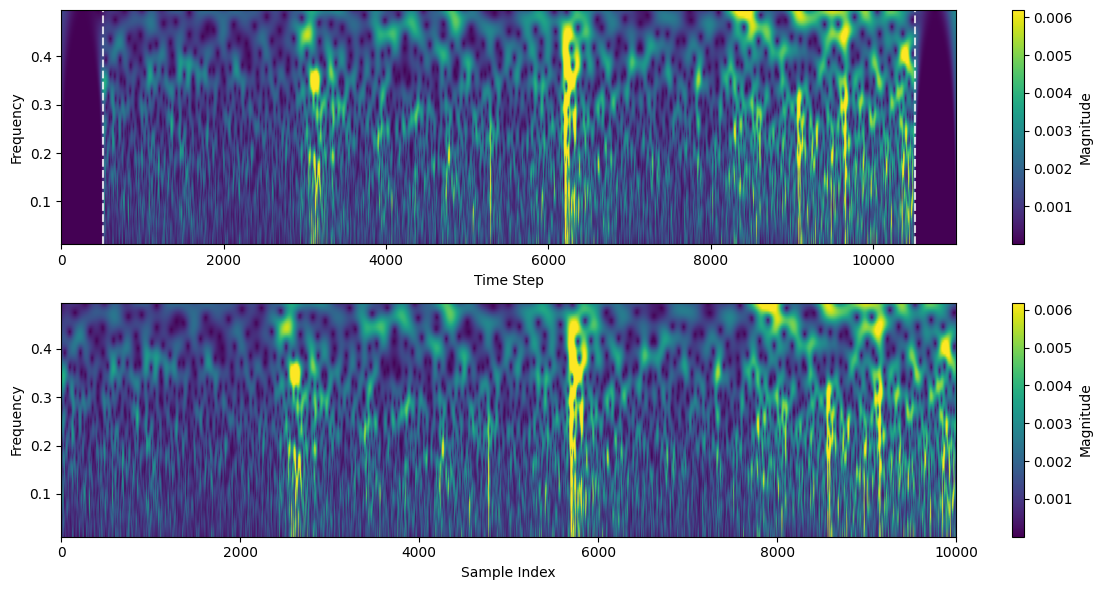

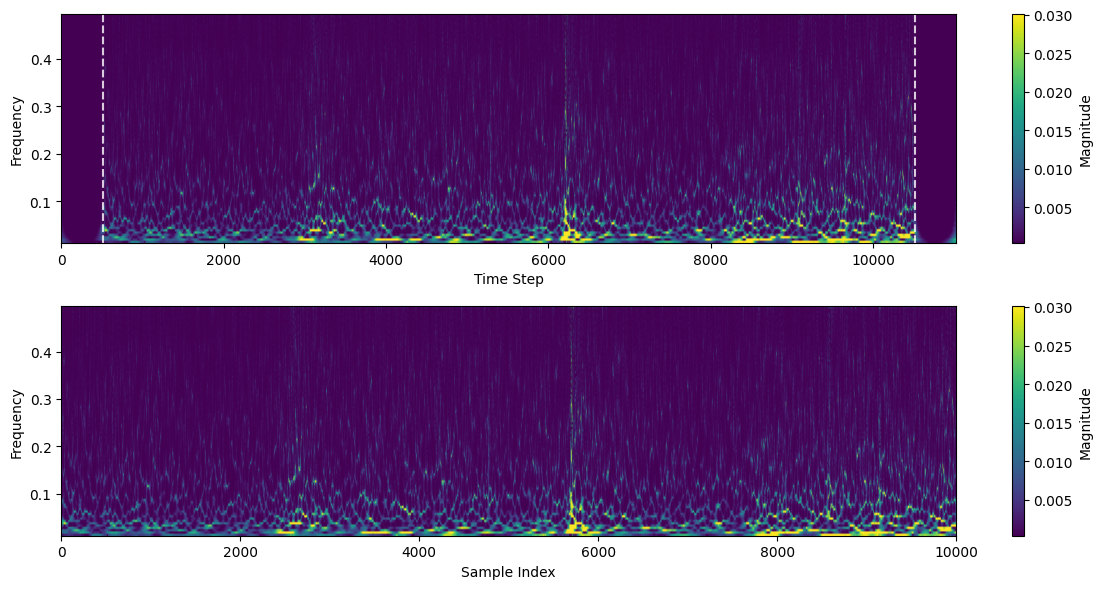

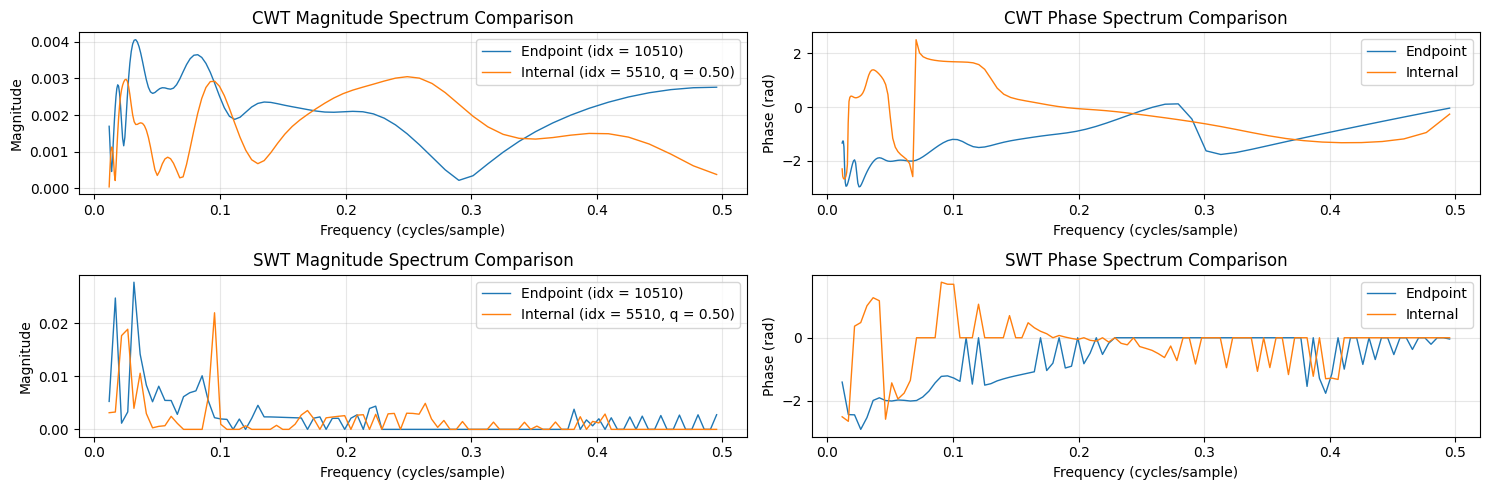

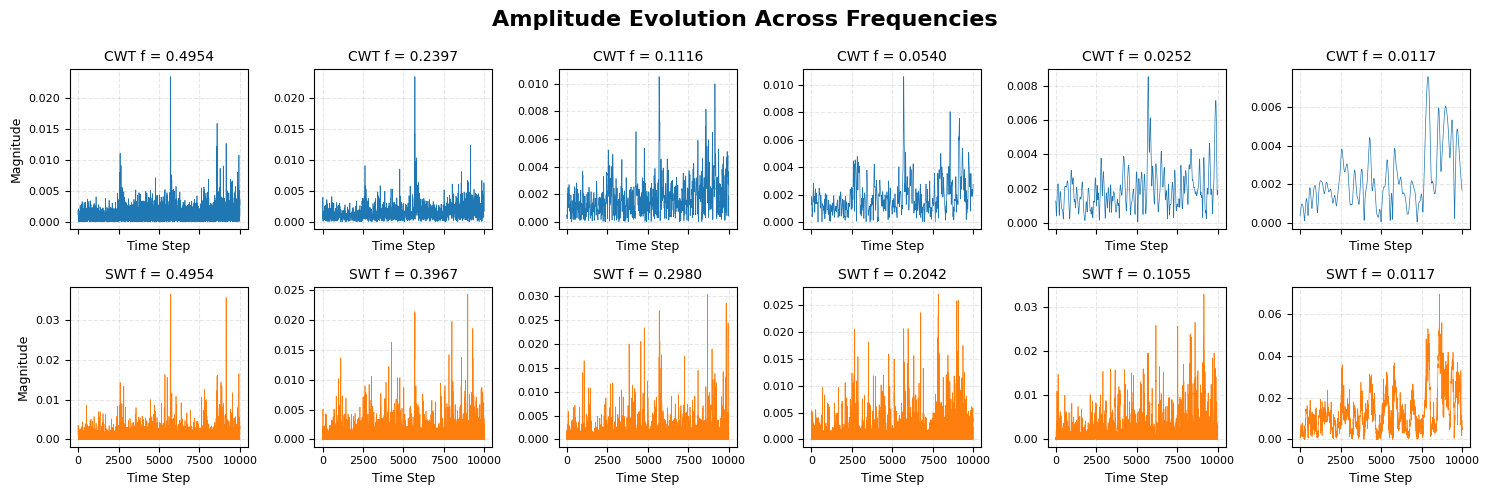

72214

In [19]:
def single_window_analysis():
    ''' 执行单窗口 CWT+SWT 分析并可视化，函数退出时强制释放内存 '''

    single_window_signal = np.log(main_continuous_resampled_timeseries['close']).diff().values[1:10001]

    # 创建 WaveletAnalyzer 分析器实例 analyzer
    analyzer = WaveletAnalyzer(
        fc = 1.5,        # 复 Morlet 小波中心频率
        fb = 1.0,        # 复 Morlet 小波带宽参数
        scale_min = 1,   # 最小尺度
        scale_max = 128, # int(len(single_window_signal) / 10), # 最大尺度
        n_scales = 128,  # 尺度数量
    )

    # 执行完整分析
    # 而后从分析结果字典中提取各类变换系数及参数
    single_window_results = analyzer.analyze(single_window_signal, extension_mode ='constant')

    cwt_coeffs = single_window_results['cwt_coeffs']  # CWT 系数矩阵: (有效尺度数 × 延拓后样本数)，复数数组，包含时频域幅值/相位信息
    cwt_freqs = single_window_results['cwt_frequencies']  # 有效频率数组: 各有效尺度对应的伪频率(cycles/sample)，已剔除超过奈奎斯特频率(0.5)的无效成分

    swt_coeffs = single_window_results['swt_coeffs']  # SWT 同步压缩系数矩阵: (频率bins数 × 延拓后样本数)，通过能量重分配提高时频聚集性
    swt_freq_grid = single_window_results['swt_freq_grid']  # SWT 频率网格: 线性离散的频率轴，用于同步压缩后的频谱映射

    extension_length = single_window_results['extension_length']  # 延拓长度: 信号两端各延拓的样本数，用于缓解边界效应，总延拓长度 = 2 * extension_length
    n_original = single_window_results['n_original']  # 原始信号长度: 输入信号的原始样本数，用于在延拓序列中定位原始信号区域

    original_start = extension_length
    original_end = extension_length + n_original  # 可视化的时候需要标记两个边界



    # 生成可视化
    plot_cwt_spectrum(cwt_coeffs, cwt_freqs, original_start, original_end)
    plot_swt_spectrum(swt_coeffs, swt_freq_grid, original_start, original_end)

    plot_boundary_effect_comparison(
        cwt_coeffs, cwt_freqs,
        swt_coeffs, swt_freq_grid,
        extension_length, n_original,
        internal_quantile = 0.5)

    plot_frequency_evolution(
        cwt_coeffs, cwt_freqs,
        swt_coeffs, swt_freq_grid,
        extension_length,
        n_original,
        n_plot = 6 )

# 执行单窗口 CWT+SWT 分析并可视化，完成后释放内存
single_window_analysis()
import gc; gc.collect()

### 3. 滚动窗口 SWT 变换

In [74]:
class OptimizedEnhancedSynchrosqueezing:
    """ 优化的同步压缩变换 - 使用向量化操作 """

    def __init__(self, cwt_transformer, frequency_bins = None):
        self.cwt = cwt_transformer
        self.coeffs = cwt_transformer.coeffs
        self.scales = cwt_transformer.valid_scales
        self.frequencies = cwt_transformer.valid_frequencies
        if frequency_bins is None:
            self.n_freq_bins = len(self.scales)
        else:
            self.n_freq_bins = frequency_bins
        self.freq_grid = np.linspace(self.frequencies.min(), self.frequencies.max(), self.n_freq_bins)

    def compute_instantaneous_frequency(self):
        phase = np.angle(self.coeffs)
        unwrapped_phase = np.unwrap(phase, axis=1)
        dp = np.zeros_like(unwrapped_phase)
        dp[:, 1:-1] = (unwrapped_phase[:, 2:] - unwrapped_phase[:, :-2]) / 2
        dp[:, 0] = unwrapped_phase[:, 1] - unwrapped_phase[:, 0]
        dp[:, -1] = unwrapped_phase[:, -1] - unwrapped_phase[:, -2]
        inst_freq = dp / (2 * np.pi)
        inst_freq = np.clip(inst_freq, 0, 0.5)
        self.inst_freq = inst_freq
        return inst_freq

    def synchrosqueeze(self, gamma = None):
        """ 向量化优化的同步压缩 """
        n_scales, n_samples = self.coeffs.shape
        inst_freq = self.compute_instantaneous_frequency()
        cwt_magnitude = np.abs(self.coeffs)

        if gamma is None:
            gamma = 0.01 * np.max(cwt_magnitude)

        mask = cwt_magnitude > gamma
        squeezed_coeffs = np.zeros((self.n_freq_bins, n_samples), dtype = np.complex128)

        for t in range(n_samples):
            valid_mask = mask[:, t]
            if not np.any(valid_mask):
                continue

            valid_freqs = inst_freq[valid_mask, t]
            valid_coeffs = self.coeffs[valid_mask, t]

            freq_indices = np.argmin(np.abs(self.freq_grid[:, None] - valid_freqs[None, :]), axis = 0)
            freq_indices = np.clip(freq_indices, 0, self.n_freq_bins - 1)

            for idx, coeff in zip(freq_indices, valid_coeffs):
                squeezed_coeffs[idx, t] += coeff

        self.squeezed_coeffs = squeezed_coeffs
        return squeezed_coeffs

    def get_squeezed_endpoint_features(self):
        endpoint_idx = self.cwt.extension_length + self.cwt.n_original - 1
        endpoint_features = self.squeezed_coeffs[:, endpoint_idx]
        return endpoint_features

In [75]:
class OptimizedWaveletAnalyzer:

    def __init__(self, fc = 1.5, fb = 1.0, scale_min = 8, scale_max = 128, n_scales = 64):
        self.wavelet = ComplexMorletWavelet(fc = fc, fb = fb)
        self.scales = np.logspace(np.log10(scale_min), np.log10(scale_max), n_scales)
        self.cwt = WaveletCWT(wavelet = self.wavelet, scales = self.scales)
        self.cwt_coeffs = None
        self.swt = None
        self.swt_coeffs = None

    def analyze(self, signal, extension_mode = 'constant', custom_extension_length = None):
        self.cwt_coeffs, valid_scales, valid_freqs = self.cwt.transform(
            signal, mode = extension_mode, extension_length = custom_extension_length)
        self.swt = OptimizedEnhancedSynchrosqueezing(self.cwt)
        self.swt_coeffs = self.swt.synchrosqueeze()
        cwt_endpoint = self.cwt.get_endpoint_features()
        swt_endpoint = self.swt.get_squeezed_endpoint_features()

        results = {
            'cwt_coeffs': self.cwt_coeffs,
            'cwt_scales': valid_scales,
            'cwt_frequencies': valid_freqs,
            'cwt_endpoint_features': cwt_endpoint,
            'swt_coeffs': self.swt_coeffs,
            'swt_freq_grid': self.swt.freq_grid,
            'swt_endpoint_features': swt_endpoint,
            'extension_length': self.cwt.extension_length,
            'n_original': self.cwt.n_original
        }
        return results

In [76]:
def rolling_window_SWT(
    signal, window_size,
    fc = 1.5, fb = 1.0,
    scale_min = 1, scale_max = 1, n_scales = 64,
    extension_mode = 'reflect'
):
    """ 滚动窗口 SWT 基础计算

    Parameters:
    signal : array_like, shape (n_total,) 输入信号序列
    window_size : int 滚动窗口长度
    fc, fb : float 复 Morlet 小波中心频率与带宽参数
    scale_min : int 最小尺度
    scale_max : int 最大尺度
    n_scales : int 尺度数量（频率分辨率）
    extension_mode : str 信号延拓模式 ('reflect', 'symmetric', 'constant', 'periodic')

    Returns:
    dict : 包含四个值矩阵与元数据
        - 'real' : ndarray (signal_length, n_freq), 实部
        - 'imag' : ndarray (signal_length, n_freq), 虚部
        - 'magnitude' : ndarray (signal_length, n_freq), 幅值
        - 'phase' : ndarray (signal_length, n_freq), 相位（弧度）
        - 'freq_grid' : ndarray (n_freq,), 频率轴
        - 'valid_start_idx' : int, 有效数据起始索引 """

    signal_length = len(signal)

    # 预初始化分析器
    analyzer = OptimizedWaveletAnalyzer(
        fc = fc, fb = fb,
        scale_min = scale_min,
        scale_max = scale_max,
        n_scales = n_scales
    )

    # 预跑第一个窗口确定频率维度
    first_window_signal = signal[:window_size]
    first_window_signal = first_window_signal[~np.isnan(first_window_signal)]

    first_result = analyzer.analyze(first_window_signal, extension_mode = extension_mode)
    n_freq = len(first_result['swt_freq_grid'])

    del first_window_signal

    # 预分配四个输出矩阵（ NaN 填充，确保与原始信号长度对齐）
    matrices = {
        'real': np.full((signal_length, n_freq), np.nan, dtype = np.float64),
        'imag': np.full((signal_length, n_freq), np.nan, dtype = np.float64),
        'magnitude': np.full((signal_length, n_freq), np.nan, dtype = np.float64),
        'phase': np.full((signal_length, n_freq), np.nan, dtype = np.float64)
    }

    valid_start = window_size - 1
    n_valid = signal_length - window_size + 1
    for i in range(valid_start, signal_length):

        if np.isnan(signal[i]): continue  # 跳过输入为 NaN 的窗口

        window = signal[i - window_size + 1 : i + 1]
        if np.any(np.isnan(window)): continue  # 如果窗口内存在任何 NaN，保持该行 NaN

        result = analyzer.analyze(window, extension_mode = extension_mode)
        coeffs = result['swt_endpoint_features']

        # 填充四矩阵
        matrices['real'][i, :] = np.real(coeffs)
        matrices['imag'][i, :] = np.imag(coeffs)
        matrices['magnitude'][i, :] = np.abs(coeffs)
        matrices['phase'][i, :] = np.angle(coeffs)

        processed_count = i - valid_start + 1
        if processed_count % 500 == 0:

            import gc; gc.collect()  # 定期垃圾回收 释放 ssqueezepy 内部临时大数组
            progress = processed_count / n_valid * 100
            print(f"SWT 进度: {progress:.1f}% ({processed_count}/{n_valid})")  # 每 n 次打印进度


    import gc; gc.collect()  # 最终清理
    return {
        **matrices,
        'freq_grid': first_result['swt_freq_grid'],
        'valid_start_idx': valid_start  # 前 valid_start 行为 NaN（含差分首值）
    }

In [23]:
rolling_window_signal = np.log(main_continuous_resampled_timeseries['close']).diff().values

rolling_window_results = rolling_window_SWT(
    signal = rolling_window_signal,
    window_size = 256 * 5, # window_size 必须 ≥ 4 ⋅ scale_max
    fc = 1.5,
    fb = 1.0,
    scale_min = 1,
    scale_max= 256,
    n_scales = 128,
    extension_mode = 'constant'  # 延拓模式: 'constant', 'symmetric', 'periodic', 'reflect'
)

SWT 进度: 0.8% (500/63511)
SWT 进度: 1.6% (1000/63511)
SWT 进度: 2.4% (1500/63511)
SWT 进度: 3.1% (2000/63511)
SWT 进度: 3.9% (2500/63511)
SWT 进度: 4.7% (3000/63511)
SWT 进度: 5.5% (3500/63511)
SWT 进度: 6.3% (4000/63511)
SWT 进度: 7.1% (4500/63511)
SWT 进度: 7.9% (5000/63511)
SWT 进度: 8.7% (5500/63511)
SWT 进度: 9.4% (6000/63511)
SWT 进度: 10.2% (6500/63511)
SWT 进度: 11.0% (7000/63511)
SWT 进度: 11.8% (7500/63511)
SWT 进度: 12.6% (8000/63511)
SWT 进度: 13.4% (8500/63511)
SWT 进度: 14.2% (9000/63511)
SWT 进度: 15.0% (9500/63511)
SWT 进度: 15.7% (10000/63511)
SWT 进度: 16.5% (10500/63511)
SWT 进度: 17.3% (11000/63511)
SWT 进度: 18.1% (11500/63511)
SWT 进度: 18.9% (12000/63511)
SWT 进度: 19.7% (12500/63511)
SWT 进度: 20.5% (13000/63511)
SWT 进度: 21.3% (13500/63511)
SWT 进度: 22.0% (14000/63511)
SWT 进度: 22.8% (14500/63511)
SWT 进度: 23.6% (15000/63511)
SWT 进度: 24.4% (15500/63511)
SWT 进度: 25.2% (16000/63511)
SWT 进度: 26.0% (16500/63511)
SWT 进度: 26.8% (17000/63511)
SWT 进度: 27.6% (17500/63511)
SWT 进度: 28.3% (18000/63511)
SWT 进度: 29.1% (18500/635

In [25]:
real_matrix = rolling_window_results['real']
imag_matrix = rolling_window_results['imag']
magnitude_matrix = rolling_window_results['magnitude']
phase_matrix = rolling_window_results['phase']

frequencies = rolling_window_results['freq_grid']     # (64,) 对应的实际频率值
frequencies_str = [f"{freq:.6f}" for freq in frequencies]  # 格式化频率值，避免科学计数法歧义

real_columns = [f"real_f{freq}Hz" for freq in frequencies_str]
imag_columns = [f"imag_f{freq}Hz" for freq in frequencies_str]
magnitude_columns = [f"magnitude_f{freq}Hz" for freq in frequencies_str]
phase_columns = [f"phase_f{freq}Hz" for freq in frequencies_str]

SWT_real = pd.DataFrame(real_matrix, columns = real_columns)
SWT_imag = pd.DataFrame(imag_matrix, columns = imag_columns)
SWT_magnitude = pd.DataFrame(magnitude_matrix, columns = magnitude_columns)
SWT_phase = pd.DataFrame(phase_matrix, columns = phase_columns)

# SWT 实部数据路径 SWT_real_path
SWT_real_path = os.path.join(CWT_SWT_path, f'SWT_real.csv')
SWT_real.to_csv(SWT_real_path, index = False)

# SWT 虚部数据路径 SWT_imag_path
SWT_imag_path = os.path.join(CWT_SWT_path, f'SWT_imag.csv')
SWT_imag.to_csv(SWT_imag_path, index = False)

# SWT 幅值数据路径 SWT_magnitude_path
SWT_magnitude_path = os.path.join(CWT_SWT_path, f'SWT_magnitude.csv')
SWT_magnitude.to_csv(SWT_magnitude_path, index = False)

# SWT 相位数据路径 SWT_phase_path
SWT_phase_path = os.path.join(CWT_SWT_path, f'SWT_phase.csv')
SWT_phase.to_csv(SWT_phase_path, index = False)


frequencies_map = pd.DataFrame({
    'frequency': frequencies,
    'freq_str': frequencies_str,
    'real_col': real_columns,
    'imag_col': imag_columns,
    'magnitude_col': magnitude_columns,
    'phase_col': phase_columns})

# SWT 频率映射表路径 frequencies_map_path
frequencies_map_path = os.path.join(CWT_SWT_path, f'frequencies_map.csv')
frequencies_map.to_csv(frequencies_map_path, index = False)

### 4. 滚动窗口 SWT 计算结果热力图

In [20]:
def plot_rolling_swt_spectrum(SWT_magnitude, valid_start_idx):
    """ 绘制滚动窗口 SWT 幅度谱 (DataFrame 版本)
    Parameters
    magnitude_df : pandas.DataFrame
        DataFrame with columns named like 'magnitude_f0.015000Hz',
        rows represent time samples (e.g., 62833, 62834...)
    valid_start_idx : int 第一个有效窗口末端索引（即第一个非 NaN 的位置） """

    # 从列名解析频率 (magnitude_f0.015000Hz -> 0.015000)
    freq_list = []
    for col in SWT_magnitude.columns:
        try:
            # 提取数字部分
            freq_str = col.replace('magnitude_f', '').replace('Hz', '')
            freq_list.append(float(freq_str))
        except (ValueError, AttributeError):
            raise ValueError(f"无法从列名 '{col}' 解析频率，请确保格式为 'magnitude_f{{频率}}Hz'")

    freq_grid = np.array(freq_list)


    mag_for_plot = SWT_magnitude.values.T # DataFrame 形状: (n_samples, n_freqs) -> 转置为 (n_freqs, n_samples)

    masked_mag = np.ma.masked_invalid(mag_for_plot) # 创建掩码，忽略 NaN 值

    valid_vals = masked_mag.compressed() # 计算颜色范围, 仅使用有效值
    if len(valid_vals) > 0:
        vmin, vmax = np.percentile(valid_vals, [1, 99])
    else: vmin, vmax = 0, 1

    fig, ax = plt.subplots(figsize = (15, 5))
    im = ax.imshow(
        masked_mag, aspect = 'auto', origin = 'lower',
        extent = [
           SWT_magnitude.index.min(), SWT_magnitude.index.max(),
           freq_grid.min(), freq_grid.max()],
        cmap = 'viridis', vmin = vmin, vmax = vmax)

    # # 标记有效区域起始位置
    # ax.axvline(
    #     x = valid_start_idx,
    #     color = 'gray', linestyle = '--',
    #     linewidth=1.5, alpha=0.8 )

    ax.set_xlabel('Time Step')
    ax.set_ylabel('Frequency (Hz)')
    ax.set_title('Rolling Window SWT Magnitude Spectrum')
    plt.colorbar(im, ax = ax, label = 'Magnitude')

    plt.tight_layout()
    plt.show()

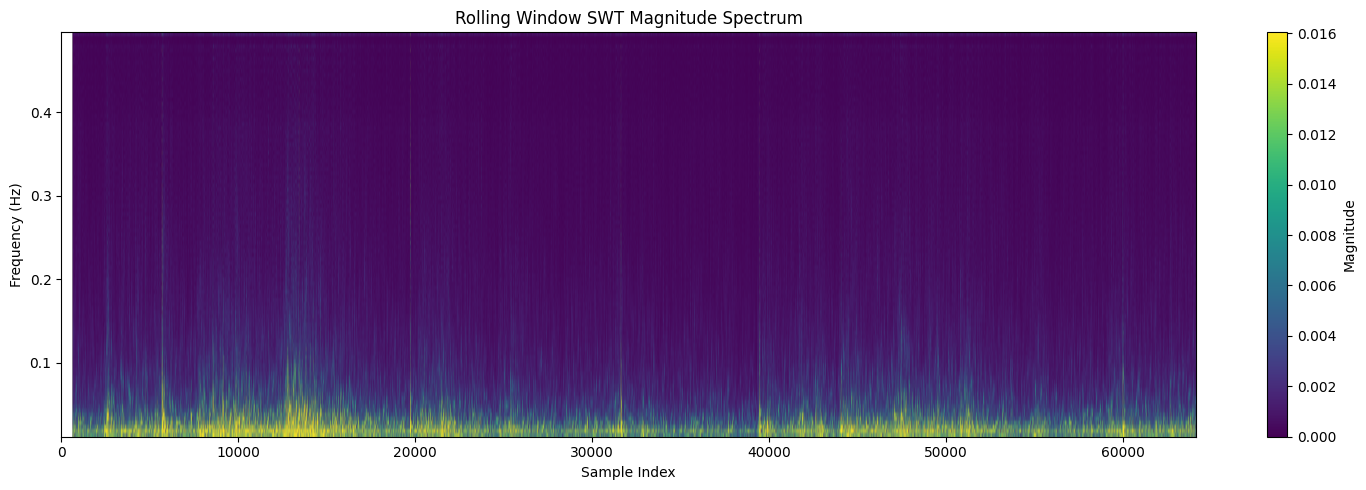

6111

In [82]:
# valid_start_idx = rolling_window_results['valid_start_idx'] # 即 window_size - 1
SWT_magnitude = pd.read_csv(SWT_magnitude_path)

plot_rolling_swt_spectrum(
    SWT_magnitude = SWT_magnitude,
    valid_start_idx = None)
import gc; gc.collect()